## 1. Import Library

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy
import sklearn

### Business Understanding

**Latar Belakang**

Arab Saudi merupakan salah satu pasar e-commerce terbesar di kawasan Timur Tengah, dengan nilai pasar mencapai USD 27,96 miliar pada tahun 2025 dan diproyeksikan tumbuh hingga USD 54,87 miliar pada tahun 2031 dengan CAGR sebesar 11,92% (Mordor Intelligence). Pertumbuhan ini didorong oleh penetrasi internet yang hampir universal (99%), cakupan jaringan 5G yang mencapai 78% populasi, serta inisiatif transformasi digital nasional di bawah payung Vision 2030.
Seiring dengan pertumbuhan ini, pasar mobil bekas (used car) di Arab Saudi juga mengalami perkembangan yang signifikan. Pasar mobil bekas diproyeksikan tumbuh dari USD 6,82 miliar pada tahun 2025 menjadi USD 11,24 miliar pada tahun 2031, dengan CAGR sebesar 8,58%, didorong oleh pertumbuhan populasi, aturan impor yang lebih ketat, kewajiban asuransi komprehensif, serta preferensi konsumen terhadap kendaraan bersertifikat (certified pre-owned) yang menawarkan riwayat servis dan laporan inspeksi yang jelas (Mordor Intelligence). Platform digital turut mempercepat siklus penjualan dan meningkatkan transparansi harga di sektor ini, menjadikan kanal online sebagai saluran dengan pertumbuhan tercepat dibanding kanal penjualan konvensional.

**Company Profile**

Syarah adalah platform marketplace online asal Arab Saudi yang didirikan pada tahun 2015 oleh Fayez Alanazi dan Salah Sharef, berkantor pusat di Riyadh,Arab Saudi. Saat ini menjadi salah satu marketplace jual-beli mobil (baru maupun bekas) terbesar di Arab Saudi berdasarkan traffic, dengan model bisnis yang mencakup penjualan langsung ke konsumen, biaya listing dan transaksi, serta layanan tambahan seperti pembiayaan dan pengantaran ke rumah.

**Problem Statement**

Dalam menjalankan bisnis jual-beli mobil bekas secara online, Syarah dituntut untuk dapat menentukan estimasi harga jual mobil yang wajar dan kompetitif berdasarkan karakteristik kendaraan seperti merek, tipe, tahun produksi, jarak tempuh, kondisi mesin, hingga wilayah penjualan. Ketidakpastian dalam menentukan harga berdampak langsung pada efisiensi transaksi dan kepercayaan pengguna platform, harga yang ditetapkan terlalu tinggi akan memperlambat perputaran unit dan menurunkan daya saing listing, sementara harga yang ditetapkan terlalu rendah akan merugikan penjual dan menurunkan potensi pendapatan dari komisi transaksi. Kondisi ini semakin kompleks karena distribusi harga mobil bekas cenderung sangat bervariasi, dengan sebagian kecil mobil bernilai jauh di atas rata-rata pasar. Tanpa model prediksi harga berbasis machine learning yang efektif untuk menganalisis atribut kendaraan secara terintegrasi, proses penentuan harga akan tetap bersifat manual, subjektif, dan rentan terhadap ketidaktransparanan harga antara penjual dan pembeli.


**Goals**

Mengembangkan model machine learning regresi yang mampu memprediksi harga jual mobil bekas yang wajar berdasarkan data historis listing dari Syarah, mencakup atribut kendaraan seperti merek, tipe, tahun produksi, jarak tempuh, dan kondisi mesin. Model ini diharapkan dapat membantu perusahaan menghasilkan estimasi harga yang lebih cepat, konsisten, dan berbasis data, sehingga mengurangi ketergantungan pada penentuan harga secara manual dan subjektif serta meningkatkan transparansi harga bagi penjual maupun pembeli.

**Analytical Approach**

Karena variabel target, *Price*, merupakan nilai numerik kontinu yang merepresentasikan harga wajar sebuah mobil bekas, permasalahan ini termasuk ke dalam kategori regresi. Model machine learning regresi akan dikembangkan untuk memprediksi harga mobil berdasarkan atribut-atribut historis dari listing, seperti merek, tipe, tahun produksi, jarak tempuh, dan kondisi mesin.

**Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**



Dataset ini berisi informasi mobil bekas yang dijual di Arab Saudi (versi mentah/unclean), terdiri dari **8.248 baris** dan **15 kolom**. Berikut deskripsi masing-masing fitur:

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| **Link** | String | URL halaman iklan mobil di situs syarah.com. Sebagian nama mobil dalam URL masih berbahasa Arab (belum diterjemahkan). |
| **Make** | String | Merek/pabrikan mobil (contoh: Toyota, Nissan, Mercedes).|
| **Type** | String | Model/tipe spesifik dari merek tersebut (contoh: Camry, Patrol, C-Class).|
| **Year** | Integer | Tahun produksi/model mobil. |
| **Origin** | String | Asal mobil: `Saudi`, `Gulf Arabic` (negara Teluk lain), `Other` (luar Teluk).|
| **Color** | String | Warna eksterior mobil (15 kategori, contoh: Black, White, Silver).|
| **Options** | String | Level kelengkapan fitur/trim kendaraan, bersifat **ordinal**: `Standard` < `Semi Full` < `Full`. Terdapat nilai kosong (109 baris). |
| **Engine_Size** | Float | Kapasitas mesin dalam liter (L). Semakin besar nilainya, umumnya tenaga mesin semakin besar namun konsumsi bahan bakar juga meningkat.|
| **Fuel_Type** | String | Jenis bahan bakar: `Gas` (bensin), `Diesel`, atau `Hybrid` (kombinasi mesin bensin + motor listrik, tidak memerlukan pengisian daya eksternal). |
| **Gear_Type** | String | Jenis transmisi: `Automatic` atau `Manual`. |
| **Condition** | String | Kondisi mobil. Hanya berisi **satu nilai unik** (`Used`) di seluruh baris, sehingga tidak memberikan informasi tambahan untuk analisis. |
| **Mileage** | Integer | Jarak tempuh kendaraan dalam **kilometer (km)**.|
| **Region** | String | Wilayah/kota penjualan mobil di Arab Saudi (27 wilayah, contoh: Riyadh, Jeddah, Dammam). |
| **Price** | String | Harga jual mobil dalam Riyal Saudi (SAR). Bertipe **String** (bukan Integer) karena bercampur dengan nilai teks `"Negotiable"` untuk mobil yang harganya bisa dinego. |
| **Negotiable** | Boolean | Menunjukkan apakah harga mobil dapat dinegosiasikan (`True`) atau bersifat tetap/fixed (`False`). Konsisten 100% dengan nilai `"Negotiable"` di kolom Price. |

## 2. Load Data

In [2]:
df = pd.read_csv("dataset/UsedCarsSA_Unclean_EN.csv")
df.head()

,Link,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
0,https://syarah.com/%D9%83%D8%B1%D8%A7%D9%8A%D8...,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,Used,103000,Riyadh,114000,False
1,https://syarah.com/%D9%86%D9%8A%D8%B3%D8%A7%D9...,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,Used,5448,Riyadh,Negotiable,True
2,https://syarah.com/online/%D9%86%D9%8A%D8%B3%D...,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,Used,72418,Riyadh,27500,False
3,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,Used,114154,Riyadh,43000,False
4,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,Used,41912,Riyadh,59500,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Link         8248 non-null   str    
 1   Make         8248 non-null   str    
 2   Type         8248 non-null   str    
 3   Year         8248 non-null   int64  
 4   Origin       8153 non-null   str    
 5   Color        8248 non-null   str    
 6   Options      8139 non-null   str    
 7   Engine_Size  5982 non-null   float64
 8   Fuel_Type    8248 non-null   str    
 9   Gear_Type    8174 non-null   str    
 10  Condition    8248 non-null   str    
 11  Mileage      8248 non-null   int64  
 12  Region       8248 non-null   str    
 13  Price        8248 non-null   str    
 14  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), str(11)
memory usage: 2.5 MB


## 3. Buang Kolom yang Tidak Diperlukan
`Link` tidak diperlukan untuk analisis, dan `Condition` hanya punya satu nilai unik (`Used`) sehingga tidak berguna.

In [4]:
df["Condition"].value_counts()

Condition
Used    8248
Name: count, dtype: int64

In [5]:
df.drop(["Link", "Condition"], axis=1, inplace=True)
df.head()

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,Negotiable,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False


## 4. Cek Data Kosong & Duplikat

In [6]:
df.isna().sum()

Make              0
Type              0
Year              0
Origin           95
Color             0
Options         109
Engine_Size    2266
Fuel_Type         0
Gear_Type        74
Mileage           0
Region            0
Price             0
Negotiable        0
dtype: int64

In [7]:
df_copy = df.copy()
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8248 non-null   str    
 1   Type         8248 non-null   str    
 2   Year         8248 non-null   int64  
 3   Origin       8153 non-null   str    
 4   Color        8248 non-null   str    
 5   Options      8139 non-null   str    
 6   Engine_Size  5982 non-null   float64
 7   Fuel_Type    8248 non-null   str    
 8   Gear_Type    8174 non-null   str    
 9   Mileage      8248 non-null   int64  
 10  Region       8248 non-null   str    
 11  Price        8248 non-null   str    
 12  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), str(9)
memory usage: 1.2 MB


In [8]:
df_copy.drop_duplicates(inplace=True)
df_copy.info()

<class 'pandas.DataFrame'>
Index: 8179 entries, 0 to 8247
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8179 non-null   str    
 1   Type         8179 non-null   str    
 2   Year         8179 non-null   int64  
 3   Origin       8084 non-null   str    
 4   Color        8179 non-null   str    
 5   Options      8070 non-null   str    
 6   Engine_Size  5925 non-null   float64
 7   Fuel_Type    8179 non-null   str    
 8   Gear_Type    8105 non-null   str    
 9   Mileage      8179 non-null   int64  
 10  Region       8179 non-null   str    
 11  Price        8179 non-null   str    
 12  Negotiable   8179 non-null   bool   
dtypes: bool(1), float64(1), int64(2), str(9)
memory usage: 1.3 MB


## 5. Isi Data Kosong
- `Engine_Size`, `Gear_Type`, `Options` -> diisi dengan nilai tersering (modus) per kombinasi Make+Type
- `Origin` -> diisi dengan `'Unknown'`
- Baris yang masih kosong setelah itu (tidak ada referensi modus) di-drop

In [9]:
def most_frequent(series):
    vc = series.value_counts()
    return vc.index[0] if len(vc) > 0 else pd.NA

# Engine_Size, Gear_Type, Options -> isi pakai modus per Make+Type
for col in ['Engine_Size', 'Gear_Type', 'Options']:
    fill_values = df_copy.groupby(['Make', 'Type'])[col].transform(most_frequent)
    df_copy[col] = df_copy[col].fillna(fill_values)

# Origin -> isi dengan 'Unknown'
df_copy['Origin'] = df_copy['Origin'].fillna('Unknown')

print(df_copy.isna().sum())

Make            0
Type            0
Year            0
Origin          0
Color           0
Options         7
Engine_Size    83
Fuel_Type       0
Gear_Type       6
Mileage         0
Region          0
Price           0
Negotiable      0
dtype: int64


In [10]:
# Drop sisa baris yang masih kosong (tidak ada referensi modus untuk diisi)
df_copy.dropna(inplace=True)
df_copy.info()

<class 'pandas.DataFrame'>
Index: 8096 entries, 0 to 8247
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Make         8096 non-null   str   
 1   Type         8096 non-null   str   
 2   Year         8096 non-null   int64 
 3   Origin       8096 non-null   str   
 4   Color        8096 non-null   str   
 5   Options      8096 non-null   str   
 6   Engine_Size  8096 non-null   object
 7   Fuel_Type    8096 non-null   str   
 8   Gear_Type    8096 non-null   str   
 9   Mileage      8096 non-null   int64 
 10  Region       8096 non-null   str   
 11  Price        8096 non-null   str   
 12  Negotiable   8096 non-null   bool  
dtypes: bool(1), int64(2), object(1), str(9)
memory usage: 1.2+ MB


In [11]:
df = df_copy
df.info()

<class 'pandas.DataFrame'>
Index: 8096 entries, 0 to 8247
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Make         8096 non-null   str   
 1   Type         8096 non-null   str   
 2   Year         8096 non-null   int64 
 3   Origin       8096 non-null   str   
 4   Color        8096 non-null   str   
 5   Options      8096 non-null   str   
 6   Engine_Size  8096 non-null   object
 7   Fuel_Type    8096 non-null   str   
 8   Gear_Type    8096 non-null   str   
 9   Mileage      8096 non-null   int64 
 10  Region       8096 non-null   str   
 11  Price        8096 non-null   str   
 12  Negotiable   8096 non-null   bool  
dtypes: bool(1), int64(2), object(1), str(9)
memory usage: 1.2+ MB


## 6. Perbaiki Kolom Price
Kolom `Price` bertipe teks karena ada nilai `"Negotiable"` bercampur dengan angka. Kolom ini konsisten 1:1 dengan kolom `Negotiable` (boolean), jadi `"Negotiable"` diganti jadi `0`.

In [12]:
print('Price == "Negotiable":', (df['Price'] == 'Negotiable').sum())
print('Negotiable == True   :', (df['Negotiable'] == True).sum())

Price == "Negotiable": 2550
Negotiable == True   : 2550


In [13]:
df['Price'] = df['Price'].replace('Negotiable', 0).astype(int)
df["Price"].describe()

count    8.096000e+03
mean     5.371059e+04
std      7.266478e+04
min      0.000000e+00
25%      0.000000e+00
50%      3.700000e+04
75%      7.300000e+04
max      1.150000e+06
Name: Price, dtype: float64

## 7. Perbaiki Kolom Type
Beberapa nilai `Type` adalah hasil salah terjemahan mesin dari bahasa Arab. Sudah divalidasi lewat halaman kategori resmi syarah.com.

In [14]:
suspicious_types = [
    'Furniture', 'Ciocca', 'Behbehani', 'POS24',
    'Gamble', 'Montero2', 'Copper', 'Koranado'
]
anomali_type = df[df['Type'].isin(suspicious_types)]
print(f"Jumlah baris dengan Type mencurigakan: {len(anomali_type)}")
anomali_type[['Make', 'Type', 'Year', 'Price']]

Jumlah baris dengan Type mencurigakan: 191


,Make,Type,Year,Price
17,MINI,Copper,2016,83000
24,Toyota,Furniture,2021,145000
108,Toyota,Furniture,2019,105000
129,Toyota,Furniture,2019,120000
146,Toyota,Furniture,2017,60000
...,...,...,...,...
7952,Toyota,Furniture,2009,0
8115,Toyota,Furniture,2013,55000
8223,Toyota,Furniture,2012,41000
8235,Toyota,Furniture,2020,0


In [15]:
# Drop baris dengan Type 'Behbehani' (ini nama dealer)
df = df[df['Type'] != 'Behbehani']

# Mapping tervalidasi lewat halaman kategori resmi syarah.com
type_mapping = {
    'Furniture': 'Fortuner',       # Toyota Fortuner
    'Ciocca': 'Sequoia',           # Toyota Sequoia
    'POS24': 'Short Bonnet',       # Mercedes truk klasik "Short Bonnet" (1959-1995)
    'Gamble': 'Ghibli',            # Maserati Ghibli
    'Montero2': 'Mountaineer',     # Mercury Mountaineer
    'Copper': 'Cooper',            # MINI Cooper
    'Koranado': 'Korando',         # SsangYong Korando
}

df['Type'] = df['Type'].replace(type_mapping)

## 8. Buang Baris Make = 'Other'
Baris-baris ini kebanyakan bukan mobil penumpang (motor, bus, alat berat), bukan salah kategori.

In [16]:
df[df['Make'] == 'Other']

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
2849,Other,Other,2012,Other,Blue,Full,2.4,Gas,Automatic,150,Jazan,0,True
3004,Other,Other,2009,Saudi,Black,Full,2.4,Gas,Automatic,218000,Riyadh,0,True
3078,Other,Other,2019,Other,White,Full,8.0,Diesel,Manual,24643,Qassim,330000,False
4800,Other,Other,2009,Other,Orange,Standard,2.4,Diesel,Manual,1300,Al-Medina,26000,False
5115,Other,Other,2007,Saudi,Red,Standard,3.5,Gas,Manual,125,Qassim,7000,False
5130,Other,Other,1992,Saudi,White,Semi Full,2.2,Gas,Manual,120000,Jeddah,0,True
5437,Other,Other,2011,Other,White,Standard,2.4,Diesel,Manual,100000,Jazan,0,True
5530,Other,Other,2019,Saudi,Brown,Full,1.0,Gas,Manual,4000,Jeddah,39000,False
5588,Other,Other,2006,Saudi,Oily,Standard,6.5,Diesel,Manual,81250,Riyadh,0,True
5715,Other,Other,2021,Other,Yellow,Semi Full,1.2,Gas,Manual,3000,Jeddah,5500,False


In [17]:
df = df[df['Make'] != 'Other']

## 9. Perbaiki Kolom Color
`'Oily'` adalah salah terjemahan dari kata Arab `زيتي`, yang seharusnya berarti warna **Olive** (hijau zaitun), bukan "berminyak".

In [18]:
df['Color'] = df['Color'].replace({'Oily': 'Olive'})
df['Color'].value_counts()

Color
White            3500
Black             941
Silver            897
Grey              720
Another Color     539
Brown             326
Red               279
Golden            226
Blue              224
Navy              161
Bronze            159
Olive              50
Green              38
Yellow             11
Orange              9
Name: count, dtype: int64

## 9b. Perbaiki Tipe Data Engine_Size & Cek Ulang Duplikat
- `Engine_Size` berubah jadi tipe `object` setelah proses `groupby().transform()` di langkah imputasi, perlu dikembalikan ke `float`.
- Perbaikan `Type` dan `Color` sebelumnya bisa membuat baris yang tadinya berbeda jadi identik (duplikat baru), jadi perlu `drop_duplicates()` lagi di sini.

In [19]:
# Kembalikan Engine_Size ke float (sempat jadi object gara-gara groupby().transform())
print('Engine_Size dtype sebelum:', df['Engine_Size'].dtype)
df['Engine_Size'] = df['Engine_Size'].astype(float)
print('Engine_Size dtype sesudah:', df['Engine_Size'].dtype)

Engine_Size dtype sebelum: object
Engine_Size dtype sesudah: float64


In [20]:
# Drop duplikat lagi, karena perbaikan Type/Color bisa menyatukan baris yang tadinya beda
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Baris sebelum: {before}, sesudah: {after}, duplikat baru terhapus: {before - after}')

Baris sebelum: 8080, sesudah: 8077, duplikat baru terhapus: 3


## 10. Cek Akhir (Kolom Categorical)
Memastikan tidak ada lagi data kosong dan seluruh kolom teks sudah bersih.

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 8077 entries, 0 to 8247
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8077 non-null   str    
 1   Type         8077 non-null   str    
 2   Year         8077 non-null   int64  
 3   Origin       8077 non-null   str    
 4   Color        8077 non-null   str    
 5   Options      8077 non-null   str    
 6   Engine_Size  8077 non-null   float64
 7   Fuel_Type    8077 non-null   str    
 8   Gear_Type    8077 non-null   str    
 9   Mileage      8077 non-null   int64  
 10  Region       8077 non-null   str    
 11  Price        8077 non-null   int64  
 12  Negotiable   8077 non-null   bool   
dtypes: bool(1), float64(1), int64(3), str(8)
memory usage: 1.2 MB


In [22]:
str_cols = df.select_dtypes(include='str').columns

for col in str_cols:
    if col in ('Type'):  # terlalu banyak nilai unik untuk ditampilkan
        continue
    print(f'Unique Value Of Columns {col}')
    print(df[col].unique().tolist())
    print('='*50)
    print()

Unique Value Of Columns Make
['Chrysler', 'Nissan', 'Hyundai', 'Honda', 'Toyota', 'GMC', 'Chevrolet', 'Mercedes', 'MINI', 'Lexus', 'Land Rover', 'Mazda', 'Ford', 'Kia', 'Genesis', 'Cadillac', 'Geely', 'MG', 'Jeep', 'INFINITI', 'Dodge', 'Ferrari', 'Great Wall', 'Jaguar', 'GAC', 'Renault', 'Suzuki', 'Peugeot', 'Changan', 'HAVAL', 'BMW', 'Rolls-Royce', 'Porsche', 'Mitsubishi', 'Isuzu', 'Subaru', 'Zhengzhou', 'Audi', 'Lincoln', 'Volkswagen', 'Daihatsu', 'Bentley', 'FAW', 'Chery', 'Aston Martin', 'Mercury', 'Fiat', 'BYD', 'Classic', 'Hummer', 'Maserati', 'SsangYong', 'Lifan', 'Foton', 'Tata', 'Victory Auto', 'Škoda', 'Iveco']

Unique Value Of Columns Origin
['Saudi', 'Gulf Arabic', 'Other', 'Unknown']

Unique Value Of Columns Color
['Black', 'White', 'Silver', 'Grey', 'Navy', 'Bronze', 'Red', 'Another Color', 'Golden', 'Brown', 'Blue', 'Olive', 'Green', 'Orange', 'Yellow']

Unique Value Of Columns Options
['Full', 'Standard', 'Semi Full']

Unique Value Of Columns Fuel_Type
['Gas', 'Diesel',

## Kolom Mileage

In [27]:
df['Mileage'].nlargest(10)

7590    20000000
4595     9999999
5202     4900000
4797     4691232
7728     4500000
6789     4430000
7462     4358765
1606     4090000
3503     4010000
5689     4000000
Name: Mileage, dtype: int64

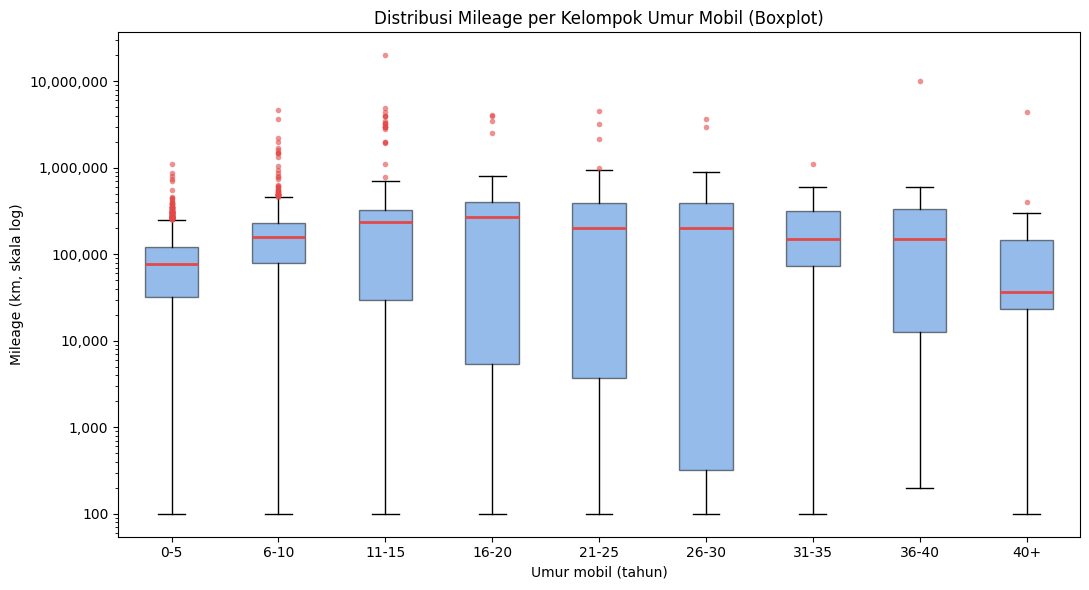

In [23]:
current_year = 2021
df['car_age'] = (current_year - df['Year']).clip(lower=0)

bins = [-1,5,10,15,20,25,30,35,40,100]
labels = ['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','40+']
df['age_group'] = pd.cut(df['car_age'], bins=bins, labels=labels)

# Siapkan data per kelompok umur (list of array untuk boxplot)
data_per_group = [df[df['age_group']==grp]['Mileage'].dropna().values for grp in labels]

fig, ax = plt.subplots(figsize=(11,6))
ax.boxplot(
    data_per_group,
    tick_labels=labels,
    patch_artist=True,
    flierprops=dict(marker='o', markerfacecolor='#e34948', markersize=4, markeredgecolor='none', alpha=0.6),
    medianprops=dict(color='#e34948', linewidth=2),
    boxprops=dict(facecolor='#2a78d6', alpha=0.5)
)

ax.set_xlabel('Umur mobil (tahun)')
ax.set_ylabel('Mileage (km, skala log)')
ax.set_title('Distribusi Mileage per Kelompok Umur Mobil (Boxplot)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [24]:
def upper_bound(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return q3 + 1.5 * (q3 - q1)

def flag_outlier(group):
    return group['Mileage'] > upper_bound(group['Mileage'])

df['mileage_outlier'] = df.groupby('age_group', observed=True, group_keys=False).apply(flag_outlier)
print('Total outlier:', df['mileage_outlier'].sum())

Total outlier: 179
